In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# lets say usally you do 2000 tx day <--- cust ABC
# sudden at mid night ==> 10000 tx in 1 day <--- cust ABC
# sudden spike in tx volume ==> anomaly / fraud / attack

# fraud_detection_model.predict()
# we will pass customer info. -> given trx is fraud or not
# classification model
# output ==> fraud / not fraud

In [7]:
# load the data
data = pd.read_csv('seed.csv')
data.head(2)

# here 
# 0 indicates normal trx
# 1 indicates fraud trx

# do you have imblance data or not
data['is_fraud'].value_counts(normalize=True)
# oversampling or undersampling
# SMOTE??

is_fraud
0    0.98218
1    0.01782
Name: proportion, dtype: float64

### 01. Data Analysis

In [12]:
# list the columns
data.columns.tolist()


['txn_id',
 'timestamp',
 'txn_type',
 'channel',
 'amount',
 'status',
 'payer_upi',
 'payee_upi',
 'payer_device_id',
 'payee_device_id',
 'payer_city',
 'payee_city',
 'is_fraud',
 'payer_lat',
 'payer_lon',
 'payee_lat',
 'payee_lon']

In [13]:
# problem statement
# CHECK IF GIVEN TRASANCTION is fraudulent or not
# input give to you
# 'txn_id',
#  'timestamp',
#  'txn_type',
#  'channel',
#  'amount',
#  'status',
#  'payer_upi',
#  'payee_upi',
#  'payer_device_id',
#  'payee_device_id',
#  'payer_city',
#  'payee_city',
#  'is_fraud',
#  'payer_lat',
#  'payer_lon',
#  'payee_lat',
#  'payee_lon']


# define each column
# 'txn_id' : unique transaction identifier
# 'timestamp' : date and time of the transaction
# 'txn_type' : type of transaction (e.g., payment, transfer)
# 'channel' : channel through which the transaction was made (e.g., mobile, web
# 'amount' : amount of money involved in the transaction
# 'status' : status of the transaction (e.g., completed, pending, failed)
# 'payer_upi' : unique identifier for the payer's UPI account
# 'payee_upi' : unique identifier for the payee's UPI account
# 'payer_device_id' : unique identifier for the payer's device
# 'payee_device_id' : unique identifier for the payee's device
# 'payer_city' : city of the payer
# 'payee_city' : city of the payee
# 'is_fraud' : target variable indicating whether the transaction is fraudulent (1) or
# not (0)
# 'payer_lat' : latitude of the payer's location
# 'payer_lon' : longitude of the payer's location
# 'payee_lat' : latitude of the payee's location
# 'payee_lon' : longitude of the payee's location

# feature engineering ideas
# 1. Time-based features: Extract features like hour of the day, day of the week,
# and month from the timestamp to capture temporal patterns in fraudulent
# transactions.
# 2. Transaction amount features: Create features such as log-transformed amount,
# amount bins, or amount deviation from the user's average transaction amount to
# identify unusual spending behavior.
# 3. Geographical features: Calculate the distance between payer and payee using
# their latitude and longitude. This can help identify transactions that occur
# over unusually long distances.
# 4. Device features: Count the number of unique devices used by the payer and
# payee. Multiple devices may indicate suspicious activity. 
# 5. Frequency features: Calculate the number of transactions made by the payer
# and payee within a specific time window (e.g., last hour, last day) to identify
# rapid transaction patterns.
# 6. Channel features: Create binary features for each transaction channel to
# capture channel-specific fraud patterns.
# 7. Status features: Create binary features for each transaction status to
# capture status-specific fraud patterns.

# which feature can be more important
# 1. amount
# 2. time of transaction
# 3. location (payer_city, payee_city, payer_lat, payer_lon, payee_lat, payee_lon)
# 4. device_id (payer_device_id, payee_device_id)
# 5. channel
# 6. txn_type


### Feature engineering

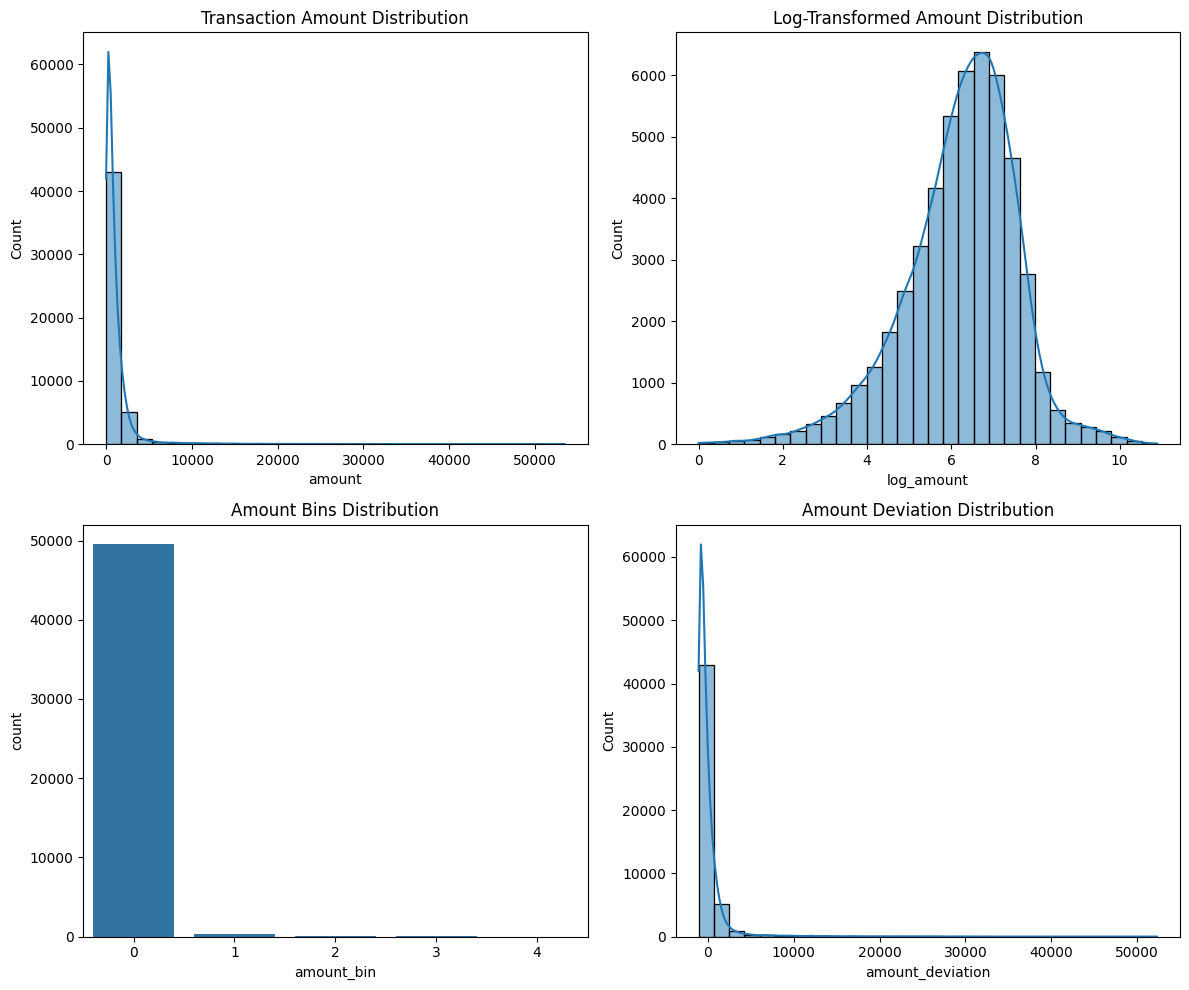

In [10]:
#1. Time-based features: Extract features like hour of the day, day of the week,
# and month from the timestamp to capture temporal patterns in fraudulent
# transactions.
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['hour'] = data['timestamp'].dt.hour
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['month'] = data['timestamp'].dt.month

# 2. Transaction amount features: Create features such as log-transformed amount,
# amount bins, or amount deviation from the user's average transaction amount to
# identify unusual spending behavior.
data['log_amount'] = np.log1p(data['amount'])
data['amount_bin'] = pd.cut(data['amount'], bins=5, labels=False)
data['amount_deviation'] = data['amount'] - data['amount'].mean()   

# lets plot amount , log_amount , amount_bin , amount_deviation
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(data['amount'], bins=30, ax=axs[0, 0], kde=True).set_title('Transaction Amount Distribution')
sns.histplot(data['log_amount'], bins=30, ax=axs[0, 1], kde=True).set_title('Log-Transformed Amount Distribution')
sns.countplot(x='amount_bin', data=data, ax=axs[1, 0]).set_title('Amount Bins Distribution')
sns.histplot(data['amount_deviation'], bins=30, ax=axs[1, 1], kde=True).set_title('Amount Deviation Distribution')
plt.tight_layout()
plt.show()

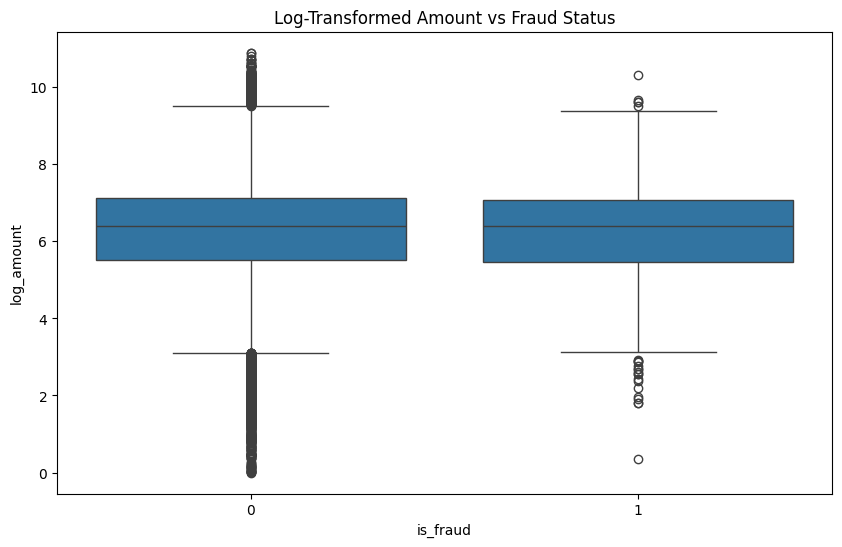

In [12]:
# lets analyze amount vs is_fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='log_amount', data=data)
plt.title('Log-Transformed Amount vs Fraud Status')
plt.show()

In [14]:
# 3. Geographical features: Calculate the distance between payer and payee using
# their latitude and longitude. This can help identify transactions that occur
# over unusually long distances.
from geopy.distance import geodesic 
def calculate_distance(row):
    payer_coords = (row['payer_lat'], row['payer_lon'])
    payee_coords = (row['payee_lat'], row['payee_lon'])
    return geodesic(payer_coords, payee_coords).km

data['distance'] = data.apply(calculate_distance, axis=1)
data[['payer_lat', 'payer_lon', 'payee_lat', 'payee_lon', 'distance']].head()

,payer_lat,payer_lon,payee_lat,payee_lon,distance
0,13.010152,80.149609,19.268977,72.943460,1035.853285
1,26.902490,75.647761,18.641976,73.826701,933.657547
2,13.037115,80.321958,22.524512,88.253898,1344.547411
3,17.575641,78.349395,28.725076,77.362832,1238.890107
4,12.930532,80.142929,12.914867,77.569873,279.227694
